## 1. 투시 보정하기

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

# ============================
# 0. 경로 정의
# ============================
ROI_FOLDER = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212"
SCALE_CSV = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251212_pixel_scale_map.csv"
OUT_CORRECTED = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_corrected/251207-251212"

os.makedirs(OUT_CORRECTED, exist_ok=True)


In [2]:

# ============================
# 1. pixel_scale_map 기반 이미지 필터링
# ============================
scale_df = pd.read_csv(SCALE_CSV)
scale_names = set(scale_df["image_name"].astype(str))

print(f"ROI_FOLDER: {ROI_FOLDER}")

# Search for images recursively in ROI_FOLDER
roi_images = glob(os.path.join(ROI_FOLDER, "**", "*.jpg"), recursive=True) + \
             glob(os.path.join(ROI_FOLDER, "**", "*.png"), recursive=True)

print(f"재귀적으로 탐색된 총 이미지 개수 (필터링 전): {len(roi_images)}")

filtered_images = []
for path in roi_images:
    name = os.path.basename(path)
    if name in scale_names:
        filtered_images.append(path)

print(f"[1단계] 매칭된 이미지 개수: {len(filtered_images)}")
print("예시 5개:", filtered_images[:5])


ROI_FOLDER: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212
재귀적으로 탐색된 총 이미지 개수 (필터링 전): 7296
[1단계] 매칭된 이미지 개수: 1878
예시 5개: ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212/251212/bed21_20251212_084257_cam1.jpg', '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212/251212/bed08_20251212_083909_cam0.jpg', '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212/251212/bed19_20251212_083708_cam1.jpg', '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/2. ROI_BOX/251207-251212/251212/bed19_20251212_083708_cam0.jpg', '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/

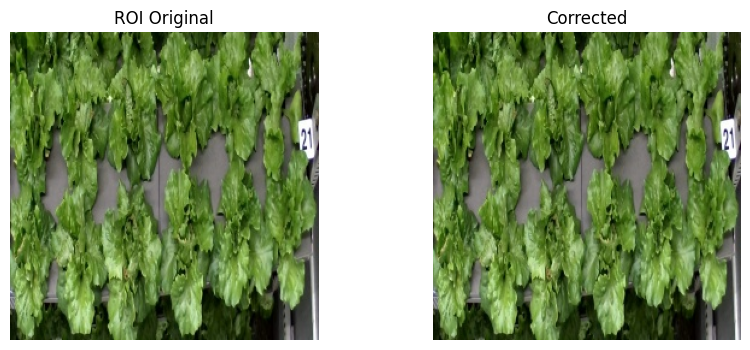

투시 보정 진행중:   0%|          | 0/1878 [00:00<?, ?it/s]

=== [1단계] 투시 보정 완료 ===
corrected 이미지 폴더: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_corrected/251207-251212


In [4]:

# ============================
# 2. 투시 보정 함수
# ============================
def perspective_correct(img):
    h, w = img.shape[:2]
    # 템플릿 기반(정사각) 보정 – 이후 refine 가능
    src = np.float32([[0,0], [w-1,0], [w-1,h-1], [0,h-1]])
    dst = np.float32([[0,0], [w-1,0], [w-1,h-1], [0,h-1]])
    M = cv2.getPerspectiveTransform(src, dst)
    corrected = cv2.warpPerspective(img, M, (w, h))
    return corrected

def _process_single_image_for_perspective_correction(image_path, output_folder, correction_function):
    base_name = os.path.basename(image_path)
    output_name = base_name.replace(".jpg", "_corrected.png").replace(".png", "_corrected.png")
    output_path = os.path.join(output_folder, output_name)

    img = cv2.imread(image_path)
    if img is not None:
        corrected_img = correction_function(img)
        cv2.imwrite(output_path, corrected_img)
    else:
        print(f"Warning: Could not read image {image_path}")


# ============================
# 3. 전체 실행 (보정만) - 병렬 처리 및 진행 바 추가
# ============================

# 샘플 시각화 (첫 번째 이미지에 대해서만)
if filtered_images:
    first_path = filtered_images[0]
    first_img = cv2.imread(first_path)
    if first_img is not None:
        first_corrected = perspective_correct(first_img)

        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1); plt.title("ROI Original")
        plt.imshow(cv2.cvtColor(first_img, cv2.COLOR_BGR2RGB)); plt.axis("off")

        plt.subplot(1,2,2); plt.title("Corrected")
        plt.imshow(cv2.cvtColor(first_corrected, cv2.COLOR_BGR2RGB)); plt.axis("off")
        plt.show()

# 병렬 처리로 모든 이미지에 투시 보정 적용
# n_jobs=-1 은 모든 CPU 코어를 사용하라는 의미
Parallel(n_jobs=-1)(delayed(_process_single_image_for_perspective_correction)(
    path, OUT_CORRECTED, perspective_correct) for path in tqdm(filtered_images, desc="투시 보정 진행중"))

print("=== [1단계] 투시 보정 완료 ===")
print("corrected 이미지 폴더:", OUT_CORRECTED)


## 2. Grid split 수행 코드

In [5]:
import os
import cv2
from glob import glob

# ============================
# 0. 경로 정의
# ============================
CORRECTED_FOLDER = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_corrected/251207-251212"
OUT_GRID = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212"

os.makedirs(OUT_GRID, exist_ok=True)


# ============================
# GRID SPLIT 함수 (6×2)
# ============================
def grid_split(img, out_folder, base_name):
    h, w = img.shape[:2]
    cell_h = h // 2
    cell_w = w // 6

    os.makedirs(out_folder, exist_ok=True)

    idx = 0
    for row in range(2):
        for col in range(6):
            y1 = row * cell_h
            y2 = (row + 1) * cell_h
            x1 = col * cell_w
            x2 = (col + 1) * cell_w

            crop = img[y1:y2, x1:x2]
            save_path = os.path.join(out_folder, f"{base_name}_{idx:02d}.png")
            cv2.imwrite(save_path, crop)
            idx += 1

In [6]:

# ============================
# 실행: corrected된 이미지 전체에 대해 grid split (병렬 + 남은시간 표시)
# ============================
corrected_images = glob(os.path.join(CORRECTED_FOLDER, "*.png"))

total = len(corrected_images)
print(f"[2단계] GRID split 대상 이미지 개수: {total}")

from concurrent.futures import ThreadPoolExecutor
import time
from tqdm import tqdm

def process_image(path):
    name = os.path.basename(path).replace(".png", "")
    img = cv2.imread(path)
    if img is None:
        print("이미지 읽기 실패:", path)
        return

    save_dir = os.path.join(OUT_GRID, name)
    grid_split(img, save_dir, name)

# 병렬 처리 + 진행률 + 남은시간 표시
start_time = time.time()

with ThreadPoolExecutor(max_workers=8) as executor:
    list(tqdm(executor.map(process_image, corrected_images), total=total, desc="GRID SPLIT 진행중"))

elapsed = time.time() - start_time
print(f"=== [2단계] GRID split 완료 (총 소요시간: {elapsed/60:.2f}분) ===")
print("grid 이미지 폴더:", OUT_GRID)


[2단계] GRID split 대상 이미지 개수: 1878



GRID SPLIT 진행중: 100%|██████████| 1878/1878 [03:59<00:00,  7.85it/s]

=== [2단계] GRID split 완료 (총 소요시간: 3.99분) ===
grid 이미지 폴더: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212


In [7]:
import os

# 접미사를 제거할 대상 경로
TARGET_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212"
SUFFIX_TO_REMOVE = "_corrected"

print(f"대상 경로: {TARGET_PATH}")
print(f"제거할 접미사: '{SUFFIX_TO_REMOVE}'")

# os.walk를 사용하여 하위 폴더와 파일을 모두 탐색 (topdown=False로 하면 깊은 곳부터 처리)
for root, dirs, files in os.walk(TARGET_PATH, topdown=False):
    # 파일 이름 변경
    for name in files:
        if SUFFIX_TO_REMOVE in name:
            old_path = os.path.join(root, name)
            new_name = name.replace(SUFFIX_TO_REMOVE, "")
            new_path = os.path.join(root, new_name)
            try:
                os.rename(old_path, new_path)
                print(f"Renamed file: {old_path} -> {new_path}")
            except OSError as e:
                print(f"Error renaming file {old_path}: {e}")

    # 디렉토리 이름 변경 (파일 변경 후)
    for name in dirs:
        if SUFFIX_TO_REMOVE in name:
            old_path = os.path.join(root, name)
            new_name = name.replace(SUFFIX_TO_REMOVE, "")
            new_path = os.path.join(root, new_name)
            try:
                os.rename(old_path, new_path)
                print(f"Renamed directory: {old_path} -> {new_path}")
            except OSError as e:
                print(f"Error renaming directory {old_path}: {e}")

print("'_corrected' 접미사 제거 작업이 완료되었습니다.")


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Renamed file: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212/bed45_20251211_192130_cam1_corrected/bed45_20251211_192130_cam1_corrected_11.png -> /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212/bed45_20251211_192130_cam1_corrected/bed45_20251211_192130_cam1_11.png
Renamed file: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212/bed03_20251211_191655_cam1_corrected/bed03_20251211_191655_cam1_corrected_00.png -> /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/3. ROI_LETTUCE/bed_grid_split/251207-251212/bed03_20251211_191655_cam1_corrected/bed03_20251211_191655_cam1_00.png
Renamed fi